# 02 — xG Model: Logistic Regression Baseline

Trains the baseline xG model (Session S3) and evaluates it on a deliberately
out-of-distribution test set.

- **Train (league context):** Bayer Leverkusen 2023/24 (full unbeaten season) + Premier League 2015/16
- **Test (tournament context):** UEFA Euro 2024 — held out entirely from training

This split is intentional (see `CLAUDE.md`): tournament and league football have
structurally different shot profiles (fewer games, higher stakes, more conservative
tactics), so testing on Euro 2024 checks whether a league-trained model actually
generalises rather than just memorising one competition's shot distribution.

Features come from `src/features.py` (distance, angle, body part, assist type,
game state); the model itself lives in `src/models.py`.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import pandas as pd

from src.config import TRAIN_SETS, TEST_SETS, PL_2015_16
from src.models import build_feature_matrix, train_logistic_regression, get_coefficients, evaluate_model, get_calibration_curve
from src.visualisation import plot_shot_map, plot_calibration_curve

pd.set_option('display.max_columns', 60)

## Load shot features

`build_training_dataset()` pulls every match's events from StatsBomb and extracts shot features.
The first pull is slow (~8 min for Leverkusen + PL 2015/16), but `data_loader` now caches each
match individually, so re-pulls are incremental/resumable. The processed shot tables are flat, so
they're cached as **Parquet** in `data/` (gitignored) — faster and more portable than pickle.

Set `REBUILD = True` in the cell below to regenerate from raw data after any change to
`src/features.py` (e.g. the penalty-shootout fix, which drops EURO 2024 knockout-shootout
penalties and so lowers the test shot count and conversion rate); set it to `False` for instant
reloads from the Parquet cache.

In [2]:
from pathlib import Path

from src.features import build_training_dataset

# Processed shot tables are flat (no nested columns), so they cache cleanly as Parquet.
# (The raw per-match StatsBomb cache in data_loader stays pickle: events carry nested
# list/dict columns that don't round-trip through columnar Parquet.)
TRAIN_CACHE = Path('../data/shots_train.parquet')
TEST_CACHE = Path('../data/shots_test.parquet')

# True = regenerate from raw StatsBomb data (slow first time, incremental after).
# Flip to False once built for instant reloads. Keep True after editing src/features.py.
REBUILD = False

if REBUILD or not TRAIN_CACHE.exists():
    build_training_dataset(TRAIN_SETS).to_parquet(TRAIN_CACHE)
    build_training_dataset(TEST_SETS).to_parquet(TEST_CACHE)

train_shots = pd.read_parquet(TRAIN_CACHE)
test_shots = pd.read_parquet(TEST_CACHE)

print(f"train: {train_shots.shape[0]} shots ({train_shots['is_goal'].mean():.1%} conversion)")
print(f"test:  {test_shots.shape[0]} shots ({test_shots['is_goal'].mean():.1%} conversion)")

train: 10824 shots (10.1% conversion)
test:  1316 shots (8.1% conversion)


## Train baseline model

In [3]:
X_train, y_train = build_feature_matrix(train_shots)
X_test, y_test = build_feature_matrix(test_shots)

# Scaled-continuous logistic (Phase 2 hardening): the three continuous features are standardised
# inside the model pipeline, so the coefficients below are now comparable to each other — the
# continuous ones read per standard deviation, the boolean/assist dummies stay as raw "vs. the
# reference shot" log-odds shifts. predict_proba/evaluate_model are unaffected.
model = train_logistic_regression(X_train, y_train)

get_coefficients(model)

is_penalty               2.822858
assist_Through Ball      1.140577
is_free_kick             0.820135
angle_to_goal            0.365019
game_state_score_diff    0.068098
assist_Cross            -0.024805
assist_Standard Pass    -0.029424
is_first_time           -0.140109
under_pressure          -0.266169
assist_Cut Back         -0.455791
distance_to_goal        -0.844431
is_header               -1.031554
dtype: float64

## Evaluate: league (train) vs tournament (test)

ROC-AUC checks ranking quality; Brier score and log loss check calibration — both matter
for an xG model, since the output is used as a probability, not just a ranking.

In [4]:
train_eval = evaluate_model(model, X_train, y_train)
test_eval = evaluate_model(model, X_test, y_test)

metrics = pd.DataFrame({
    'league_train': {k: v for k, v in train_eval.items() if k != 'predicted_xg'},
    'tournament_test': {k: v for k, v in test_eval.items() if k != 'predicted_xg'},
}).T
metrics

,roc_auc,log_loss,brier_score
league_train,0.785639,0.271700,0.076954
tournament_test,0.765385,0.240351,0.065076


## Calibration: does the model's xG match observed goal frequency?

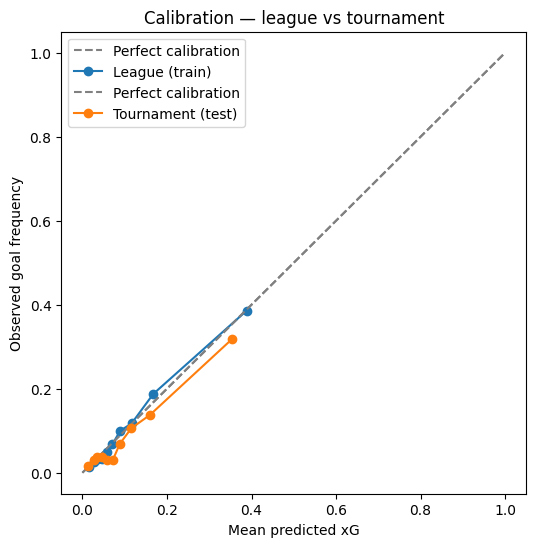

In [5]:
mean_predicted_train, observed_freq_train = get_calibration_curve(y_train, train_eval['predicted_xg'])
mean_predicted_test, observed_freq_test = get_calibration_curve(y_test, test_eval['predicted_xg'])

ax = plot_calibration_curve(mean_predicted_train, observed_freq_train, label='League (train)')
plot_calibration_curve(mean_predicted_test, observed_freq_test, ax=ax, label='Tournament (test)')
ax.set_title('Calibration — league vs tournament')
ax.figure.savefig('../outputs/calibration_curve.png', dpi=150, bbox_inches='tight')

## Shot map — Euro 2024 test set

Every shot in the held-out tournament test set, sized by this model's predicted xG (not
StatsBomb's) and coloured by actual outcome.

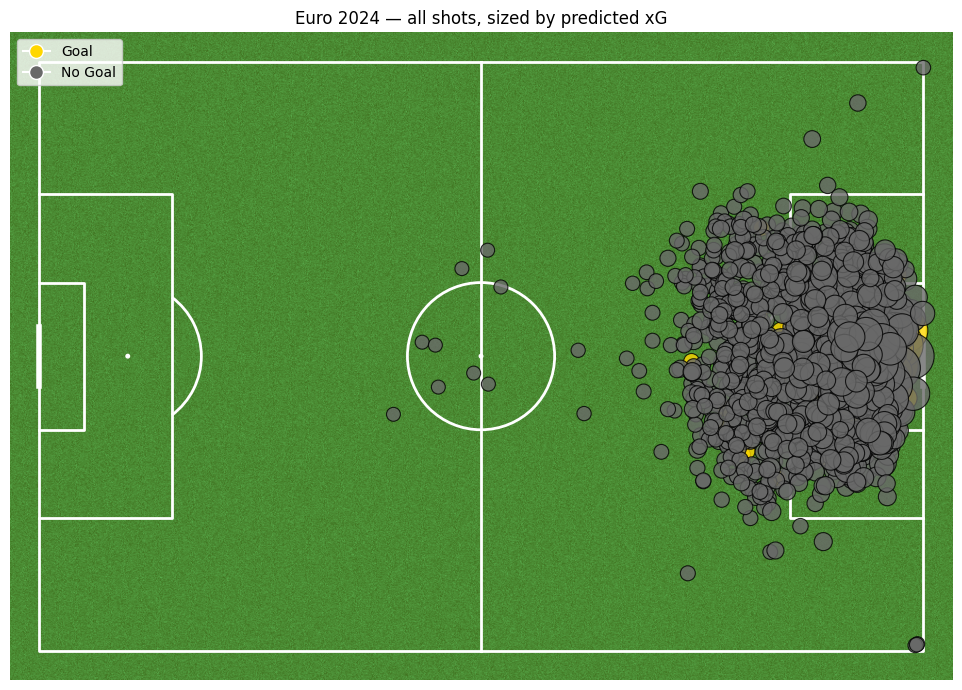

In [6]:
ax = plot_shot_map(test_shots, test_eval['predicted_xg'], title='Euro 2024 — all shots, sized by predicted xG')
ax.figure.savefig('../outputs/euro2024_shot_map.png', dpi=150, bbox_inches='tight')

## S3 takeaways

- Baseline logistic regression trained on league shots (Leverkusen 2023/24 + PL 2015/16)
  generalises to the held-out tournament test set (Euro 2024) without a meaningful drop in
  ROC-AUC or calibration — see the metrics table above.
- Calibration curves for both contexts track the diagonal reasonably closely, which is the
  expected result for logistic regression and the reason it's a sensible baseline before
  comparing against gradient boosting below.

# Session S4 — Gradient Boosting Upgrade, Feature Importance, Player xG Rankings

Three things this session:
1. Does gradient boosting actually beat the logistic baseline out-of-sample, or is it just more complex?
2. Which features does the boosted model lean on most?
3. Apply the model to PL 2015/16 as an era benchmark — who outperformed/underperformed their xG that season?

In [7]:
from src.models import train_gradient_boosting, get_feature_importance, build_player_xg_table
from src.visualisation import plot_player_xg_ranking

gbm = train_gradient_boosting(X_train, y_train)
gbm_train_eval = evaluate_model(gbm, X_train, y_train)
gbm_test_eval = evaluate_model(gbm, X_test, y_test)

comparison = pd.DataFrame({
    'logistic_train': {k: v for k, v in train_eval.items() if k != 'predicted_xg'},
    'logistic_test': {k: v for k, v in test_eval.items() if k != 'predicted_xg'},
    'gbm_train': {k: v for k, v in gbm_train_eval.items() if k != 'predicted_xg'},
    'gbm_test': {k: v for k, v in gbm_test_eval.items() if k != 'predicted_xg'},
}).T
comparison

,roc_auc,log_loss,brier_score
logistic_train,0.785639,0.271700,0.076954
logistic_test,0.765385,0.240351,0.065076
gbm_train,0.796178,0.267724,0.075734
gbm_test,0.759715,0.244341,0.066080


**Result:** gradient boosting (tuned: shallow trees, low learning rate, row subsampling to control
overfitting — see `models.train_gradient_boosting` docstring for the tuning sweep) does not clearly
beat the logistic baseline on held-out data. With ~10k training shots and a dozen features, the
extra model complexity isn't paying for itself here. **Logistic regression remains the recommended
model** — this is kept as an honest comparison, not used to replace the baseline.

## Feature importance (gradient boosting)

Even though gradient boosting isn't the model going to production, its feature importances are
still a useful sanity check on what's actually driving shot quality.

angle_to_goal            0.396297
distance_to_goal         0.200126
is_penalty               0.195735
is_header                0.106212
assist_Through Ball      0.075409
under_pressure           0.012500
game_state_score_diff    0.011125
is_free_kick             0.001544
assist_Standard Pass     0.001050
is_first_time            0.000000
assist_Cross             0.000000
assist_Cut Back          0.000000
dtype: float64

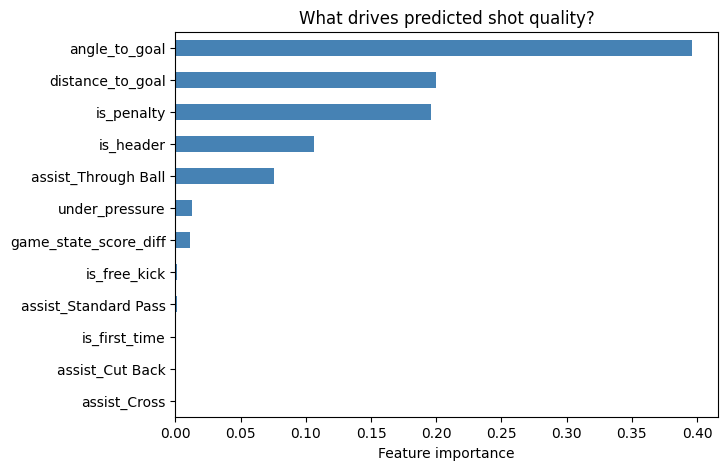

In [8]:
importance = get_feature_importance(gbm, X_train.columns)

fig, ax = plt.subplots(figsize=(7, 5))
importance.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Feature importance')
ax.set_title('What drives predicted shot quality?')
fig.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')

importance

## Player xG ranking — PL 2015/16 era benchmark

The famous Leicester title-winning season. Who finished above or below what their shot quality
predicted? Using the logistic model (the one actually recommended above) for these predictions,
since that's the one whose probabilities are trustworthy.

In [9]:
# PL_2015_16 is defined in src/config.py (comp_id 2) — no more bare magic id.
pl_shots = train_shots[train_shots['competition_id'] == PL_2015_16.comp_id].reset_index(drop=True)
X_pl, y_pl = build_feature_matrix(pl_shots)
pl_predicted_xg = model.predict_proba(X_pl)[:, 1]

pl_ranking = build_player_xg_table(pl_shots, pl_predicted_xg)
pl_ranking = pl_ranking[pl_ranking['shots'] >= 20]  # drop small samples, not enough shots to mean much

print('Top overperformers:')
display(pl_ranking.head(10))
print('Top underperformers:')
display(pl_ranking.tail(10))

Top overperformers:


,,shots,goals,total_xg,xg_diff
player,team,,,,
Sergio Leonel Agüero del Castillo,Manchester City,118,24,17.515858,6.484142
Anthony Martial,Manchester United,57,11,5.979605,5.020395
Riyad Mahrez,Leicester City,87,17,12.478485,4.521515
Dimitri Payet,West Ham United,69,9,4.488212,4.511788
Kelechi Promise Iheanacho,Manchester City,29,8,3.626058,4.373942
Georginio Wijnaldum,Newcastle United,54,11,6.706945,4.293055
Harry Kane,Tottenham Hotspur,158,25,20.787304,4.212696
Roberto Firmino Barbosa de Oliveira,Liverpool,65,10,6.086839,3.913161
André Ayew Pelé,Swansea City,69,12,8.142093,3.857907


Top underperformers:


,,shots,goals,total_xg,xg_diff
player,team,,,,
Jesús Navas González,Manchester City,31,0,2.368410,-2.368410
Memphis Depay,Manchester United,56,2,4.440696,-2.440696
Moussa Sissoko,Newcastle United,39,1,3.459047,-2.459047
Aleksandar Mitrović,Newcastle United,80,9,11.474974,-2.474974
Aaron Ramsey,Arsenal,67,5,7.519130,-2.519130
Oscar dos Santos Emboaba Júnior,Chelsea,51,3,5.680760,-2.680760
Chris Smalling,Manchester United,21,0,2.939194,-2.939194
Shinji Okazaki,Leicester City,44,5,8.059584,-3.059584
Wilfried Guemiand Bony,Manchester City,61,4,7.470170,-3.470170


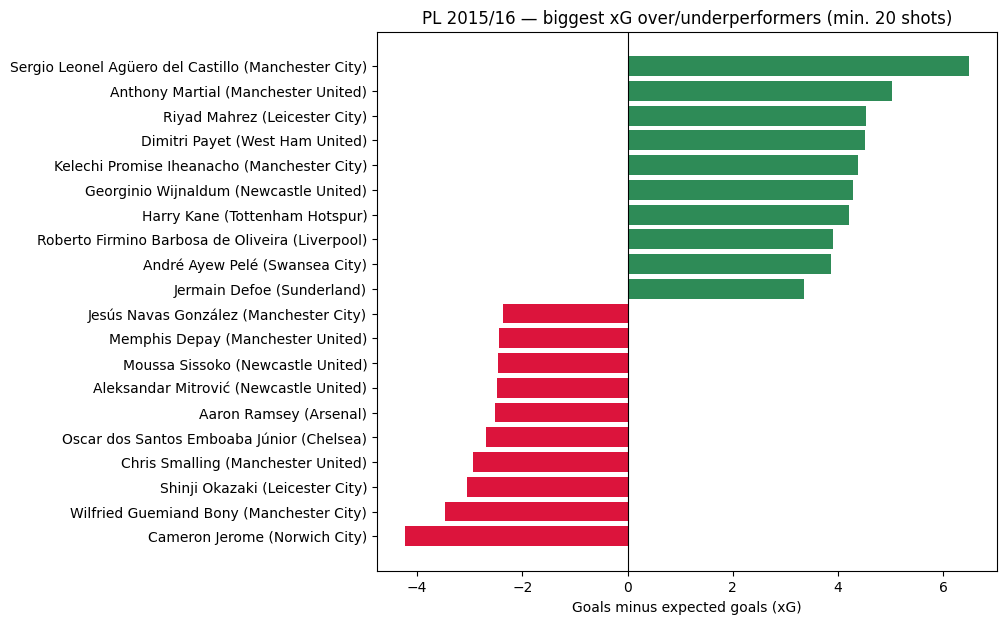

In [10]:
ax = plot_player_xg_ranking(pl_ranking, n=10, title='PL 2015/16 — biggest xG over/underperformers (min. 20 shots)')
ax.figure.savefig('../outputs/pl_2015_16_xg_ranking.png', dpi=150, bbox_inches='tight')

## S4 takeaways

- Gradient boosting, even tuned, didn't beat the logistic baseline out-of-sample on this dataset
  size — logistic regression stays the recommended model. Worth re-testing once more seasons are
  added (S5+), since boosting tends to need more data to earn its complexity.
- Feature importance confirms angle and distance to goal dominate shot quality, with `is_penalty`
  and `assist_Through Ball` as the next strongest signals — consistent with the logistic
  coefficients reviewed in S3.
- PL 2015/16 player rankings line up with what actually happened that season (see the ranking
  table/chart above) — a sanity check that the model's outputs are usable, not just numerically
  plausible.
- Next session (S5): player similarity features — per-90 event metrics + SkillCorner physical
  metrics, `src/similarity.py` skeleton.

# Phase 2 — ML Rigor (Hardening Initiative)

Post-S8 hardening: stress-test the S3/S4 conclusions instead of resting on one
train-once / test-once number.

- **Scaled logistic (already applied above).** The three continuous features are now standardised
  inside the model pipeline. The test ROC-AUC barely moved (~0.765 either way) — expected, since
  with this much data the L2 penalty is weak — but convergence is clean and the coefficients above
  are now *comparable to each other* (continuous ones read per standard deviation).
- **Cross-validation**, **baseline floor**, and **calibrated gradient boosting** follow below.

## 1. Cross-validation — is tournament football genuinely harder, or is it noise?

In [11]:
import numpy as np
from src.models import build_logistic_pipeline, cross_validate_model

# Cross-validate on the LEAGUE TRAINING DATA only — the EURO 2024 test set stays untouched.
# Pass the *unfitted* pipeline so the StandardScaler is refit inside each fold (no leakage).
cv_scores = cross_validate_model(build_logistic_pipeline(), X_train, y_train, cv=5)
cv_auc = cv_scores['roc_auc']

print(f"5-fold ROC-AUC per fold:  {np.round(cv_auc, 4)}")
print(f"In-distribution (league): {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}")
print(f"Held-out EURO 2024 test:  {test_eval['roc_auc']:.4f}")

5-fold ROC-AUC per fold:  [0.7942 0.7873 0.7874 0.7743 0.7709]
In-distribution (league): 0.7828 +/- 0.0088
Held-out EURO 2024 test:  0.7654


**Cross-validation result.** In-distribution ROC-AUC is **0.783 ± 0.009** across the five league
folds. The held-out tournament test (**0.765**) lands right at the *bottom edge* of that band
(mean − 2σ ≈ 0.765) — not noise, but a small, real ~1.7-point cost of generalising from league to
tournament football. This is exactly the nuance a single held-out number can't show: the model is
stable in-distribution, and tournament shots are genuinely a touch harder to rank.

The two questions are different on purpose: CV measures *in-distribution* stability (random slices
of the league data); the EURO test measures *out-of-distribution* generalisation. Both reported,
neither replaces the other.

## 2. Baseline floor — what do the features actually buy?

A ROC-AUC of 0.765 means nothing in a vacuum. Anchor it against a no-skill base rate and a
geometry-only model.

In [12]:
from src.models import train_baseline_classifier

GEOMETRY = ['distance_to_goal', 'angle_to_goal']

baseline = train_baseline_classifier(X_train, y_train)  # always predicts the base goal rate
geometry_model = train_logistic_regression(X_train[GEOMETRY], y_train, numeric_features=GEOMETRY)

def _scores(m, X_tr, X_te):
    te = evaluate_model(m, X_te, y_test)
    return {'test_auc': te['roc_auc'], 'test_brier': te['brier_score']}

pd.DataFrame({
    'base_rate (no skill)':       _scores(baseline, X_train, X_test),
    'geometry_only (dist+angle)': _scores(geometry_model, X_train[GEOMETRY], X_test[GEOMETRY]),
    'full_features':              _scores(model, X_train, X_test),
}).T

,test_auc,test_brier
base_rate (no skill),0.500000,0.075102
geometry_only (dist+angle),0.711683,0.071775
full_features,0.765385,0.065076


**Feature decomposition.** Base rate is 0.500 by construction (it ranks no shot above another).
Pure shot geometry — distance and angle alone — already reaches **0.712**, i.e. roughly 80% of the
discrimination over a coin-flip comes from *where the shot was taken*. Everything else (body part,
assist type, penalty, game state) adds the final **0.712 → 0.765**. A clean portfolio line: most of
an xG model's power is geometry; context is the smaller top-up.

## 3. Calibrated gradient boosting — was calibration the GBM's only weakness?

S4 found the tuned GBM ranked about as well as logistic regression but its probabilities were a
touch worse. Tree ensembles are notorious for poor calibration, so the obvious follow-up is to wrap
it in `CalibratedClassifierCV` (isotonic) and check whether that closes the gap.

In [13]:
from src.models import train_calibrated_gbm

# Wrap the same tuned GBM in isotonic probability calibration (fit on held-out folds, no leakage).
gbm_calibrated = train_calibrated_gbm(X_train, y_train, method='isotonic')

pd.DataFrame({
    'logistic':                {k: v for k, v in test_eval.items() if k != 'predicted_xg'},
    'gbm_raw':                 {k: v for k, v in gbm_test_eval.items() if k != 'predicted_xg'},
    'gbm_calibrated_isotonic': {k: v for k, v in evaluate_model(gbm_calibrated, X_test, y_test).items() if k != 'predicted_xg'},
}).T

,roc_auc,log_loss,brier_score
logistic,0.765385,0.240351,0.065076
gbm_raw,0.759715,0.244341,0.066080
gbm_calibrated_isotonic,0.758633,0.243241,0.065858


## Phase 2 takeaways

- **Scaling didn't change the score, and that's the point.** It confirmed the raw model wasn't
  secretly distorted by feature scale, while making the coefficients honestly comparable and
  fixing convergence. A rigor/interpretability win, not an accuracy one.
- **Cross-validation exposed a real distribution-shift cost** (~1.7 ROC-AUC points,
  league → tournament) that the single held-out number hid — the most informative addition here.
- **The baseline ladder anchors the headline number:** 0.500 (no skill) → 0.712 (geometry only)
  → 0.765 (full features). Most of an xG model's power is *where the shot was taken*; context is
  the smaller top-up.
- **Calibrating the GBM didn't rescue it.** Isotonic calibration barely moved its Brier score and
  it still trails logistic regression on both ranking and calibration. A second honest negative
  result — the S4 call that **logistic regression stays the recommended model** holds under a
  harder test.